# AG-HYPOPT · Trial 29

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-eight trials. Best: **trial_25** `cvm_fwhm` **0.0725** (sw 0.1972), reproduced by trial_26 0.0727;
trial_13 0.0733. The `cvm_fwhm` series (eighteen points, sw 0.18-0.38) has mean ~0.0773, std ~0.0034,
sixteen of eighteen under the KDE control (0.080328). Every other family at matched sw is clearly above
the control; the win is a gamma-channel, loss-FORM effect. Two trials remain (this and trial_30). No
divergences. Phase `trials` (28/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_29'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (28/5 trials)
ID |     ei | params
 1 | 2.3089 | {"loss_family": "kde", "sigma_weight": 0.19543935164480888}
 2 | 2.3877 | {"loss_family": "mmd_2d", "sigma_weight": 0.19665358601518887}
 3 | 2.3541 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19235415119471488}
 4 | 0.9824 | {"loss_family": "mmd_2d", "sigma_weight": 0.20541625214472212}
 5 | 1.7367 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2075813352850203}
 6 | 1.0435 | {"loss_family": "energy_2d", "sigma_weight": 0.20606697782486524}
 7 | 1.1638 | {"loss_family": "kde", "sigma_weight": 0.2026852089423792}
 8 | 1.5494 | {"loss_family": "w1_fwhm", "sigma_weight": 0.1917122626242908}
 9 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.9716301967217166}
10 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.6087034149724913}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

In this batch the EI values are a tight pack: `mmd_2d` (candidate 2, 2.3877) edges `cvm_fwhm`
(candidate 3, 2.3541) and `kde` (candidate 1, 2.3089). With only two trials left, the more valuable
choice is the winner family at the best-known sw: candidate 3 (`cvm_fwhm`, sw 0.1924) sits right at the
basin floor sw (~0.192-0.198) and adds a draw to the campaign's headline result. `mmd_2d` is already
known to be far worse (0.1755-0.1833) and would not change the conclusion.

I choose candidate 3.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 3             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.19235415119471488}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.87 | γ 8.5 -> 5.73 | NLL 1.03


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.63 | γ 14.1 -> 14.04 | NLL 0.13


Running 3nW Trans100 ... 

μ 175.71 -> 95.26 | γ 14.1 -> 13.54 | NLL 0.40



Total: 7.9 min


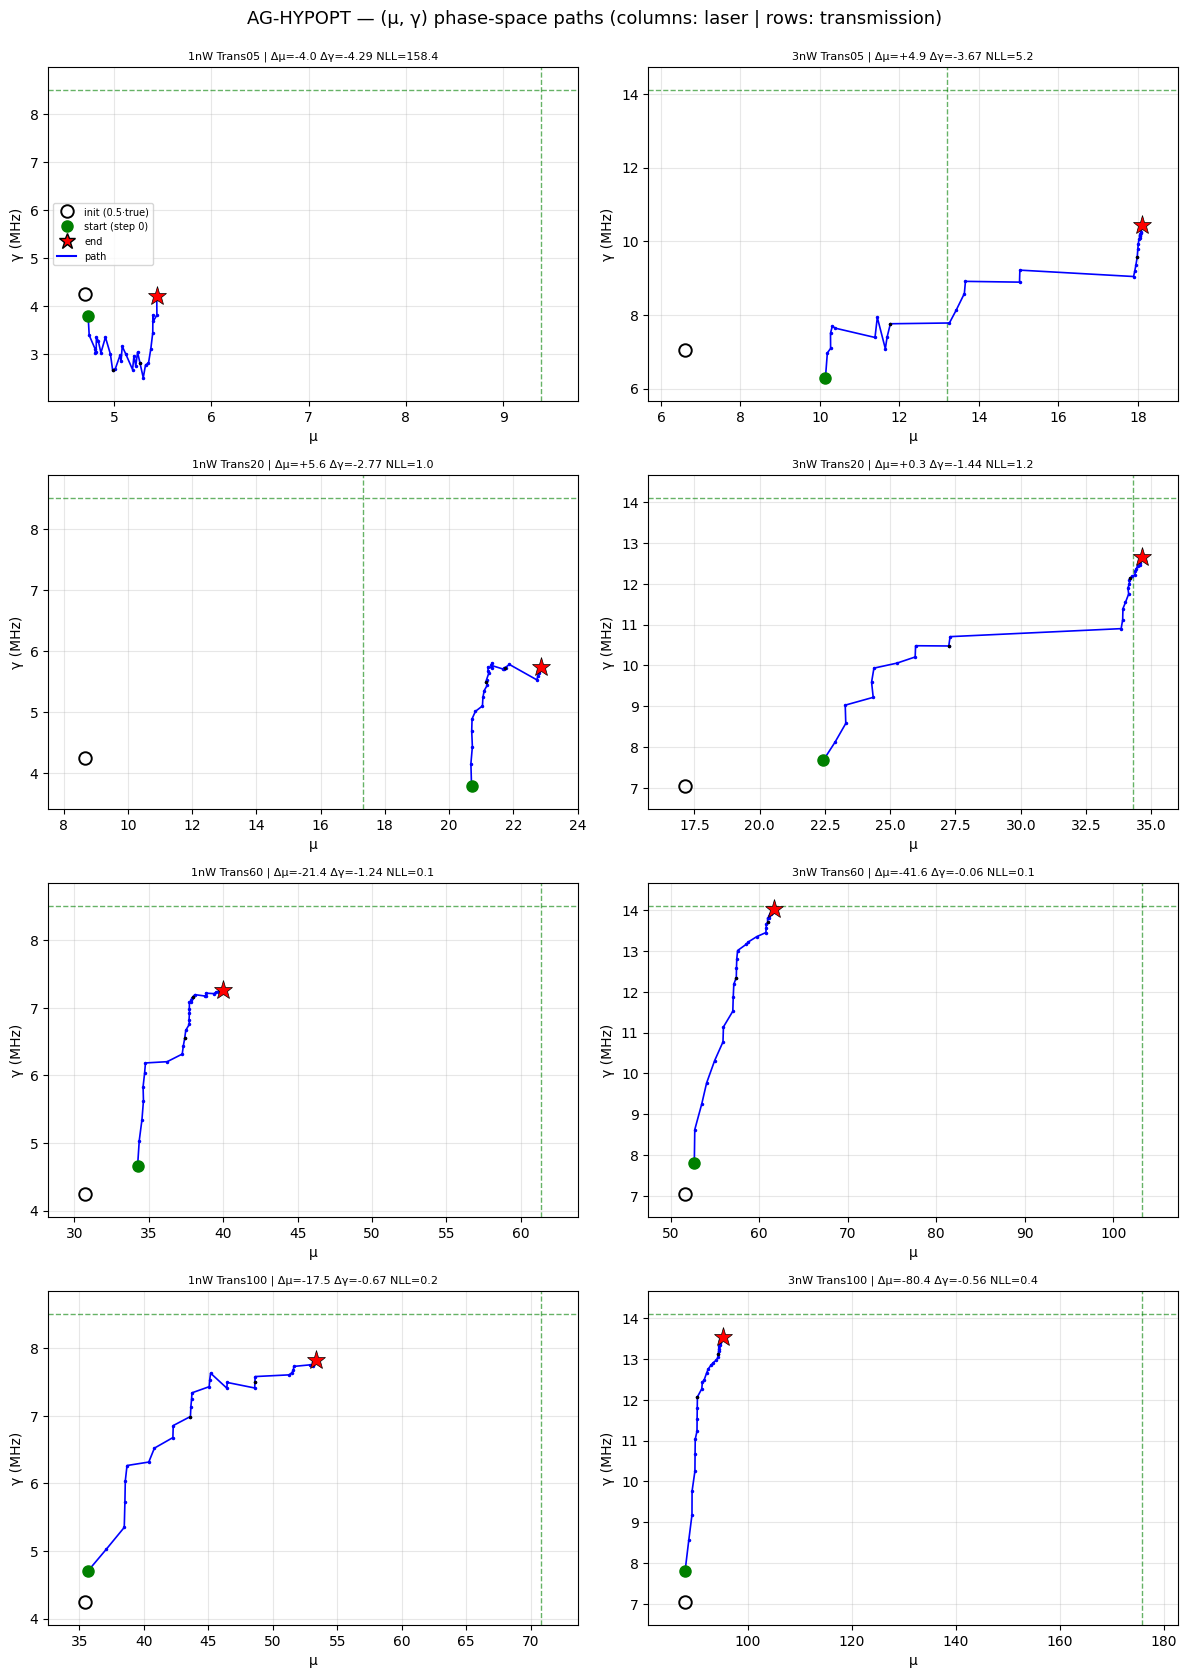

trial finished in 7.9 min
objective = 0.0799 ± 0.0205
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.87   +32.1 |     8.50    5.73   -32.6
1nW Trans60       61.37   39.95   -34.9 |     8.50    7.26   -14.6
1nW Trans100       70.82   53.35   -24.7 |     8.50    7.83    -7.9
3nW Trans05       13.20   18.09   +37.0 |    14.10   10.43   -26.0
3nW Trans20       34.28   34.63    +1.0 |    14.10   12.66   -10.2
3nW Trans60      103.20   61.63   -40.3 |    14.10   14.04    -0.4
3nW Trans100      175.71   95.26   -45.8 |    14.10   13.54    -3.9

weighted objective (T-graded, cap=1.0) = 0.0799 | diverged cells: 0
μ: RMSE 33.604 (rel 34.9%, bias -19.258) | γ: RMSE 2.341 (rel 24.2%, bias -1.836)


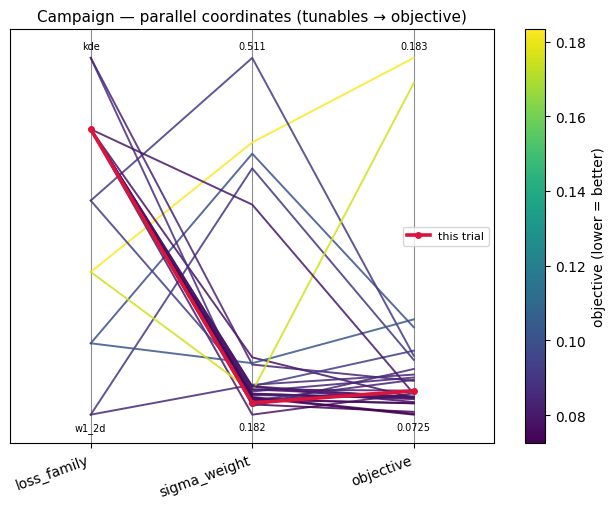

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.1924}` (candidate 3). Trial time
7.9 min, objective **0.0799 +/- 0.0205**, **0 diverged cells** - a basin draw just under the KDE control
(0.0803).

**Basin statistics.** Nineteen `cvm_fwhm` points (sw 0.18-0.38): mean ~0.0774, std ~0.0034; seventeen of
nineteen under the control.

**Per-cell behaviour / aggregates.** mu RMSE 33.60 (rel 34.9 %, bias -19.26); gamma RMSE 2.34 (rel 24.2 %,
bias -1.84).

**Summary:** `cvm_fwhm` at sw 0.1924 gives 0.0799, under the control, keeping the family mean at ~0.0774
over nineteen draws (seventeen under the control).
**Key insight:** With one trial left, the campaign conclusion is stable: `cvm_fwhm` is the only family
whose mean beats the KDE control, by ~0.003.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.1924 gives 0.0799, under the control, keeping the family mean at ~0.0774 over nineteen draws (seventeen under the control).'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'With one trial left the conclusion is stable: cvm_fwhm is the only family whose mean beats the KDE control, by ~0.003.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_29 | current best: trial_25


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_30.ipynb. Open it and follow its cells from the top.
